In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPU tersedia: []


In [2]:
# Sesuaikan path ini bila posisi notebook berbeda
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "1. FER-2013"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print("PROJECT_DIR =", PROJECT_DIR)
print("TRAIN_DIR   =", TRAIN_DIR)
print("TEST_DIR    =", TEST_DIR)

assert TRAIN_DIR.exists(), f"Folder train tidak ditemukan: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Folder test tidak ditemukan: {TEST_DIR}"


PROJECT_DIR = d:\Software Development\Projek\pak danar
TRAIN_DIR   = d:\Software Development\Projek\pak danar\1. FER-2013\train
TEST_DIR    = d:\Software Development\Projek\pak danar\1. FER-2013\test


In [3]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42
EPOCHS = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.1,
    subset="training",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.1,
    subset="validation",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Jumlah kelas:", num_classes)


Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Jumlah kelas: 7


In [4]:
# Simpan nama kelas untuk dipakai di Flask nanti
class_map = {i: name for i, name in enumerate(class_names)}
with open(MODEL_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_map, f, ensure_ascii=False, indent=2)

class_map


{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprise'}

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training=False):
    ds = ds.cache()
    if training:
        ds = ds.shuffle(1000)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)


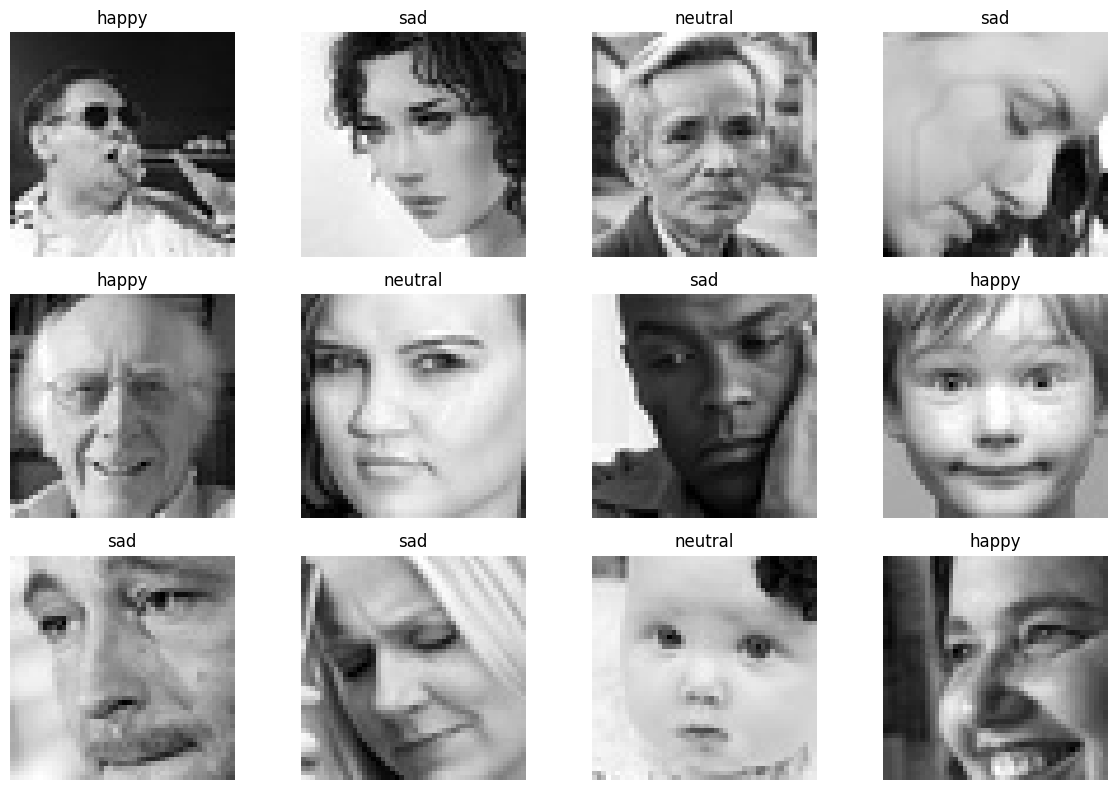

In [6]:
# Tampilkan contoh data
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap="gray")
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="augmentation",
)

model = keras.Sequential(
    [
        layers.Input(shape=(48, 48, 1)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470,055 (5.61 MB)

 Trainable params: 1,469,095 (5.60 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "emotion_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]


In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.2358 - loss: 2.1439
Epoch 1: val_accuracy improved from None to 0.27979, saving model to d:\Software Development\Projek\pak danar\models\emotion_model_best.keras

Epoch 1: finished saving model to d:\Software Development\Projek\pak danar\models\emotion_model_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 234s 558ms/step - accuracy: 0.2760 - loss: 1.9301 - val_accuracy: 0.2798 - val_loss: 1.8304 - learning_rate: 0.0010
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.3604 - loss: 1.6531
Epoch 2: val_accuracy improved from 0.27979 to 0.39826, saving model to d:\Software Development\Projek\pak danar\models\emotion_model_best.keras

Epoch 2: finished saving model to d:\Software Development\Projek\pak danar\models\emotion_model_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 241s 595ms/step - accuracy: 0.3825 - loss: 1.6010 - val_accuracy: 0.3983 - val_loss: 1.5450 - learning_rate: 0.0010
Epoch 3/20
404/404 ━━━━━━━━━━━━

In [10]:
model.save(MODEL_DIR / "emotion_model_final.keras")
print("Model final disimpan ke:", MODEL_DIR / "emotion_model_final.keras")


Model final disimpan ke: d:\Software Development\Projek\pak danar\models\emotion_model_final.keras


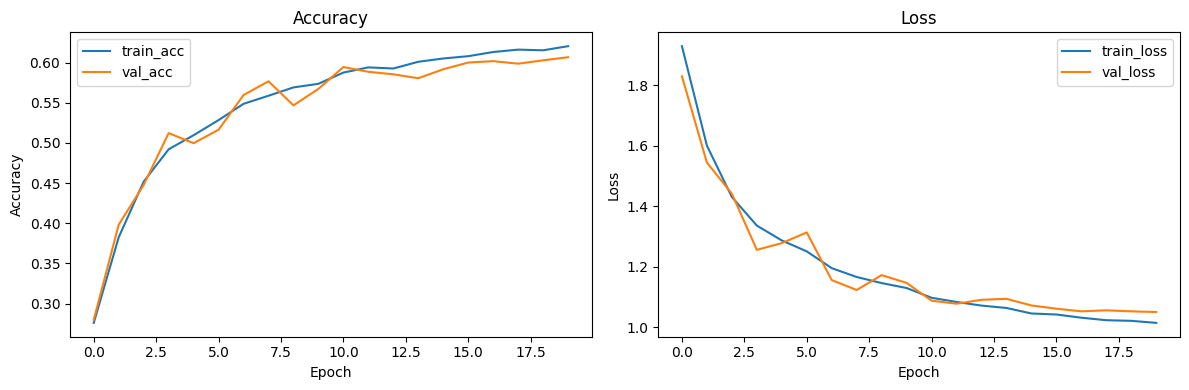

In [11]:
# Plot hasil training
history_dict = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="train_acc")
plt.plot(history_dict["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="train_loss")
plt.plot(history_dict["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# Evaluasi di test set
best_model = keras.models.load_model(MODEL_DIR / "emotion_model_best.keras")
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")


113/113 ━━━━━━━━━━━━━━━━━━━━ 43s 366ms/step - accuracy: 0.6060 - loss: 1.0502
Test loss     : 1.0502
Test accuracy : 0.6060


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


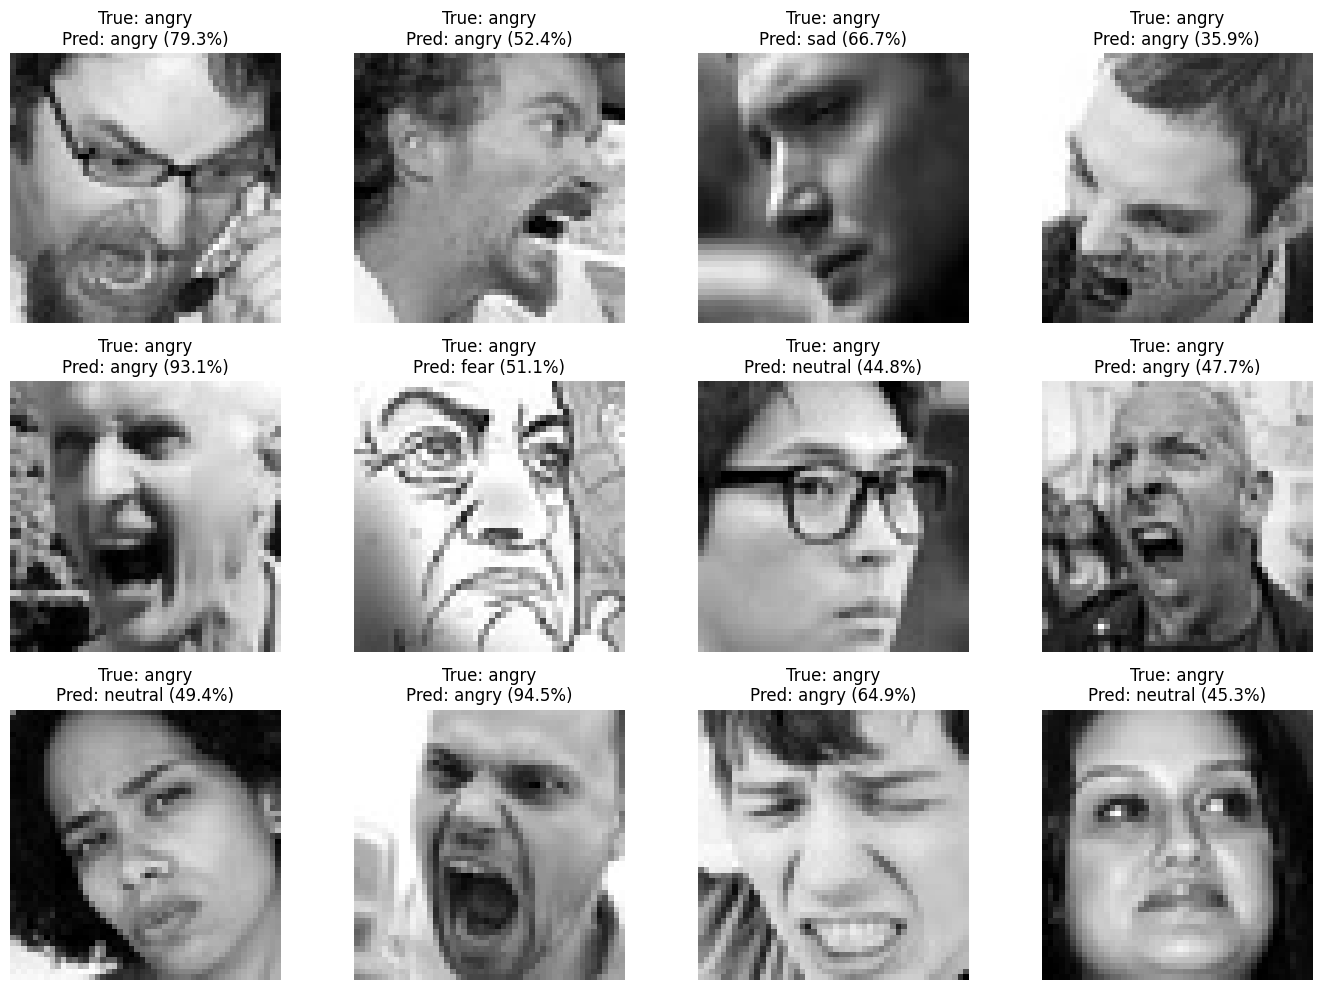

In [13]:
# Contoh prediksi 1 batch
images, labels = next(iter(test_ds))
preds = best_model.predict(images)

plt.figure(figsize=(14, 10))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(tf.squeeze(images[i]), cmap="gray")
    true_label = class_names[np.argmax(labels[i].numpy())]
    pred_label = class_names[np.argmax(preds[i])]
    conf = float(np.max(preds[i])) * 100
    plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Langkah berikutnya

Setelah file model jadi, kamu bisa pakai di `app.py` seperti ini secara garis besar:

```python
model = keras.models.load_model("models/emotion_model_best.keras")
with open("models/class_names.json", "r", encoding="utf-8") as f:
    class_map = json.load(f)
```

Lalu saat user upload gambar:
1. baca gambar
2. ubah ke grayscale
3. resize ke `48x48`
4. normalisasi
5. `model.predict()`
6. ambil label emosi tertinggi
